# Flood → Solar · M2 coupling — site-conditioned (thin)

**Peril:** Flood (riverine) · **Asset:** Solar · **Layer:** M2 (coupling) · sub-peril `riverine`

**Goal:** turn the M1 depth-at-return-period catalog into the **coupling contract M3 reads** — `exposure_fraction`
(what fraction of the plant floods) and `conditional_depth` (how deep, given flooded), per return period.

**Coupling type = site-conditioned (bucket 3, A21) — deliberately thin.** Flood is *field × susceptibility*, not
hail's areal hit-or-miss. But **BLE already gave depth-above-ground at the asset** in M1, so the field→asset step
is done. M2 mirrors wildfire's thin M2: it emits **areal exposure × conditional depth** — the two numbers M3's
depth-damage curve needs. The **per-subsystem height conditioning** (effective depth = depth − mount height) lives
in **M3** with the per-subsystem fragility, so M2 stays a clean exposure×severity emitter.

> Plan: [`m2_coupling.md`](../../../../docs/plans/flood/m2_coupling.md) · the open **event-model bridge** (RP →
> shared MC) is settled in M4. *Assumption (V1):* value ∝ area, so areal inundation proxies fraction-of-value exposed.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"

# read EVERY sub-peril catalog (JD-FL-10 fork) — riverine + pluvial; tag each row with its sub_peril
CATALOGS = {"riverine": "flood_m1_catalog_manifest.json", "pluvial": "flood_m1_catalog_pluvial_manifest.json"}
frames = []
for sp, fn in CATALOGS.items():
    f = OUT / fn
    if f.exists():
        df = pd.DataFrame(json.loads(f.read_text())["profile"])
        df["sub_peril"] = sp
        if "depth_max_m" not in df:
            df["depth_max_m"] = df["depth_wet_m"]   # pluvial has no max grid → use wet depth
        frames.append(df)
prof = pd.concat(frames, ignore_index=True)
print("M1 catalog profiles (input — all sub-perils):")
print(prof[["sub_peril", "name", "role", "rp_years", "inund_frac", "depth_wet_m", "depth_fp_m"]].to_string(index=False))

M1 catalog profiles (input — all sub-perils):
sub_peril                  name                 role  rp_years  inund_frac  depth_wet_m  depth_fp_m
 riverine  Hayhurst Texas Solar baseline (low-flood)       100       0.107        0.081       0.009
 riverine  Hayhurst Texas Solar baseline (low-flood)       500       0.161        0.176       0.028
 riverine Elizabeth Solar Plant proving (high-flood)        10       0.088        0.298       0.026
 riverine Elizabeth Solar Plant proving (high-flood)        25       0.117        0.365       0.043
 riverine Elizabeth Solar Plant proving (high-flood)        50       0.140        0.414       0.058
 riverine Elizabeth Solar Plant proving (high-flood)       100       0.162        0.464       0.075
 riverine Elizabeth Solar Plant proving (high-flood)       500       0.191        0.604       0.115
  pluvial  Hayhurst Texas Solar baseline (low-flood)        10       0.400        0.058       0.023
  pluvial  Hayhurst Texas Solar baseline (low-flood)  

## 1 · Emit the coupling contract

Per site × return period: `exposure_fraction` (= inundated fraction) and `conditional_depth_m` (= inundated-cell
mean — the depth *given* flooded). M3 must combine them as **exposure × DR(effective_depth)** — never the
footprint-average alone (that already folds exposure in, so using it *and* exposure would double-count).

In [2]:
coup = prof.rename(columns={"inund_frac": "exposure_fraction", "depth_wet_m": "conditional_depth_m"})[
    ["sub_peril", "name", "role", "rp_years", "aep", "exposure_fraction", "conditional_depth_m", "depth_max_m"]
].copy()
coup["coupling_type"] = "site_conditioned"
print(coup.to_string(index=False))

sub_peril                  name                 role  rp_years   aep  exposure_fraction  conditional_depth_m  depth_max_m    coupling_type
 riverine  Hayhurst Texas Solar baseline (low-flood)       100 0.010              0.107                0.081        0.161 site_conditioned
 riverine  Hayhurst Texas Solar baseline (low-flood)       500 0.002              0.161                0.176        0.276 site_conditioned
 riverine Elizabeth Solar Plant proving (high-flood)        10 0.100              0.088                0.298        0.298 site_conditioned
 riverine Elizabeth Solar Plant proving (high-flood)        25 0.040              0.117                0.365        0.365 site_conditioned
 riverine Elizabeth Solar Plant proving (high-flood)        50 0.020              0.140                0.414        0.414 site_conditioned
 riverine Elizabeth Solar Plant proving (high-flood)       100 0.010              0.162                0.464        1.158 site_conditioned
 riverine Elizabeth Solar P

## 2 · Plot exposure × conditional depth vs return period

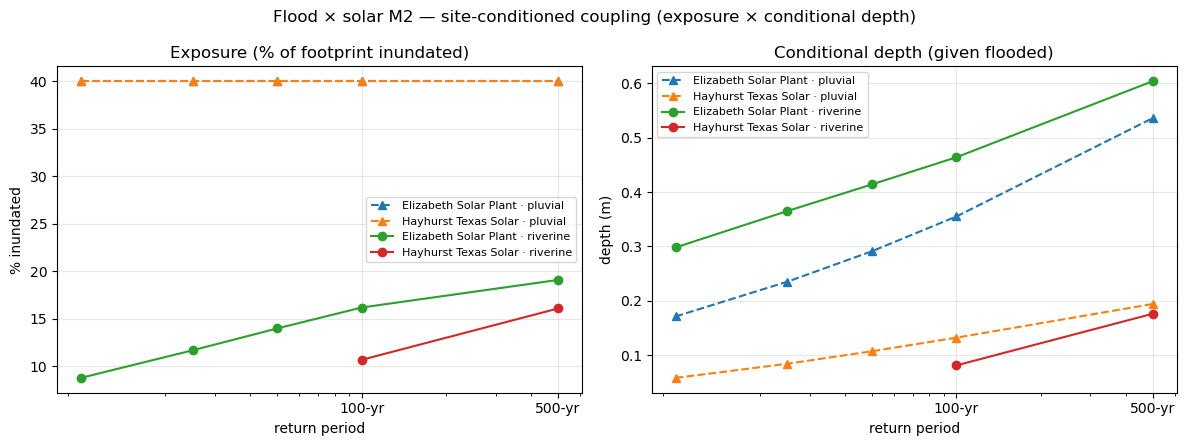

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m2_coupling.png


In [3]:
import matplotlib.pyplot as plt

fig, (axE, axD) = plt.subplots(1, 2, figsize=(12, 4.5))
for (sp, nm), g in coup.groupby(["sub_peril", "name"]):
    g = g.sort_values("rp_years")
    ls = "o-" if sp == "riverine" else "^--"
    axE.plot(g["rp_years"], g["exposure_fraction"] * 100, ls, label=f"{nm} · {sp}")
    axD.plot(g["rp_years"], g["conditional_depth_m"], ls, label=f"{nm} · {sp}")
for ax, ttl, yl in [(axE, "Exposure (% of footprint inundated)", "% inundated"),
                    (axD, "Conditional depth (given flooded)", "depth (m)")]:
    ax.set_xscale("log"); ax.set_xticks([100, 500]); ax.set_xticklabels(["100-yr", "500-yr"])
    ax.set_title(ttl); ax.set_xlabel("return period"); ax.set_ylabel(yl); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle("Flood × solar M2 — site-conditioned coupling (exposure × conditional depth)")
fig.tight_layout(); fig.savefig(OUT / "flood_m2_coupling.png", dpi=120, bbox_inches="tight")
plt.show()
print("wrote:", OUT / "flood_m2_coupling.png")

## 3 · Known-answer checks (basics-spot-on)

- **Elizabeth (high)** — exposure and/or conditional depth **rise** 100-yr → 500-yr; its exposure × depth ≫ Hayhurst.
- **Hayhurst (low)** — negligible exposure × depth (dry baseline).

In [4]:
def ed(df, eia_name, rp, sp="riverine"):
    r = df[(df.name == eia_name) & (df.rp_years == rp) & (df.sub_peril == sp)].iloc[0]
    return r["exposure_fraction"] * r["conditional_depth_m"]   # exposure × conditional depth (the coupled signal)

HIGH, LOW = "Elizabeth Solar Plant", "Hayhurst Texas Solar"
# riverine (unchanged): high site grows + dominates the dry desert baseline
ratio = ed(coup, HIGH, 500) / max(ed(coup, LOW, 500), 1e-9)
assert ed(coup, HIGH, 500) >= ed(coup, HIGH, 100) > 0, "riverine high site should grow 100→500yr"
assert ratio > 3, "riverine high site should clearly dominate the low baseline"
print(f"✓ riverine {HIGH}: exposure×depth 100yr={ed(coup,HIGH,100):.4f} → 500yr={ed(coup,HIGH,500):.4f} m (grows)")
print(f"✓ riverine {LOW}: exposure×depth 500yr={ed(coup,LOW,500):.4f} m (~{ratio:.0f}× below the high site)")
# pluvial (areal): BOTH sites carry signal (rain falls everywhere — unlike the dry-control riverine baseline)
assert ed(coup, HIGH, 500, "pluvial") >= ed(coup, HIGH, 100, "pluvial") > 0, "pluvial high site should grow"
assert ed(coup, LOW, 500, "pluvial") > 0, "pluvial wets the desert baseline too (rain is areal)"
print(f"✓ pluvial both sites carry signal: {HIGH} 500yr={ed(coup,HIGH,500,'pluvial'):.4f}, {LOW} 500yr={ed(coup,LOW,500,'pluvial'):.4f} m")
print("✓ coupling known-answer checks pass (riverine + pluvial).")

✓ riverine Elizabeth Solar Plant: exposure×depth 100yr=0.0752 → 500yr=0.1154 m (grows)
✓ riverine Hayhurst Texas Solar: exposure×depth 500yr=0.0283 m (~4× below the high site)
✓ pluvial both sites carry signal: Elizabeth Solar Plant 500yr=0.2144, Hayhurst Texas Solar 500yr=0.0776 m
✓ coupling known-answer checks pass (riverine + pluvial).


## 4 · Persist the coupling manifest (engine contract — JD-FL-4 hooks)

In [5]:
manifest = {
    "peril": "flood", "sub_peril": "riverine", "event_family_id": None, "layer": "M2",
    "coupling_type": "site_conditioned (bucket 3, A21) — thin (BLE pre-coupled depth-above-ground in M1)",
    "contract": {
        "exposure_fraction": "areal inundated fraction of footprint (≈ value exposed; value∝area V1)",
        "conditional_depth_m": "inundated-cell mean depth — severity GIVEN flooded",
        "deferred_to_M3": "per-subsystem height conditioning (effective_depth = depth − mount_height) + fragility",
    },
    "assumptions": ["value ∝ footprint area (V1)", "no double-count: M3 uses exposure × DR(conditional_depth)"],
    "rows": json.loads(coup.to_json(orient="records")),
}
(OUT / "flood_m2_coupling_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_m2_coupling_manifest.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_m2_coupling_manifest.json


## Findings & what's next

- **Thin site-conditioned coupling, emitted:** per site × RP, `(exposure_fraction, conditional_depth)` — the clean
  contract M3 reads. Elizabeth's coupled signal **grows** 100-yr → 500-yr; Hayhurst is the negligible baseline.
- **No new physics here** — BLE already coupled the depth field to the asset in M1; M2 just separates *how much*
  floods (exposure) from *how deep* (conditional depth), avoiding the footprint-average double-count.
- **Next — M3 (damage):** the house recipe — **capex-weighted subsystem** logistic depth-damage on the **effective
  depth** (`conditional_depth − mount_height`, the flood height-inversion: ground electronics drown, panels
  survive shallow), then `conditional_loss = exposure × Σ wᵢ·DRᵢ × TIV`.